# Phase 0 EDA — 威力彩歷史開獎資料

資料範圍：2008-01-24 ～ 2026-04-30（共 1,907 期）  
訓練集：1,807 期｜Holdout：最後 100 期（**Phase 2 前鎖死不看**）

---
分析目標：
1. 基本敘述統計
2. 一區號碼（1–38）頻率分布
3. 二區號碼（1–8）頻率分布
4. 年度趨勢
5. 每期六號總和分布
6. 奇偶比分布
7. 區段分布（1–13 / 14–26 / 27–38）

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "Microsoft JhengHei",   # Windows 繁中字型
    "axes.unicode_minus": False,
})

DB = Path("lottery.db")
conn = sqlite3.connect(DB)

# 只用訓練集，holdout 鎖死
df = pd.read_sql(
    "SELECT * FROM draws WHERE split='train' ORDER BY id",
    conn,
    parse_dates={"draw_date": {"format": "%Y/%m/%d"}},
)
conn.close()

print(f"訓練集：{len(df)} 期")
print(f"日期範圍：{df.draw_date.min().date()} ～ {df.draw_date.max().date()}")
df.head(3)

訓練集：1807 期
日期範圍：2008-01-24 ～ 2025-05-15


,id,draw_id,draw_date,n1,n2,n3,n4,n5,n6,n_zone2,total_sales,split
0,1,97000001,2008-01-24,3,4,16,18,36,37,2,113596500,train
1,2,97000002,2008-01-28,2,14,15,16,28,29,8,85451400,train
2,3,97000003,2008-01-31,6,9,11,13,19,23,2,82512400,train


## 1. 基本敘述統計

In [2]:
zone1_cols = ["n1", "n2", "n3", "n4", "n5", "n6"]

# 所有一區號碼攤平
all_z1 = df[zone1_cols].values.flatten()
all_z2 = df["n_zone2"].values

print("=== 一區（1–38）===")
print(f"  每期開出數：6 個（固定）")
print(f"  平均值：{all_z1.mean():.2f}（理論中位 19.5）")
print(f"  標準差：{all_z1.std():.2f}（理論 {np.std(range(1,39)):.2f}）")
print(f"  最小/最大：{all_z1.min()} / {all_z1.max()}")

print("\n=== 二區（1–8）===")
print(f"  平均值：{all_z2.mean():.2f}（理論中位 4.5）")
print(f"  標準差：{all_z2.std():.2f}（理論 {np.std(range(1,9)):.2f}）")

# 每期六號總和
df["sum6"] = df[zone1_cols].sum(axis=1)
print(f"\n=== 每期六號總和 ===")
print(df["sum6"].describe().round(2))

=== 一區（1–38）===
  每期開出數：6 個（固定）
  平均值：19.43（理論中位 19.5）
  標準差：10.95（理論 10.97）
  最小/最大：1 / 38

=== 二區（1–8）===
  平均值：4.44（理論中位 4.5）
  標準差：2.27（理論 2.29）

=== 每期六號總和 ===
count    1807.00
mean      116.61
std        24.58
min        45.00
25%        99.00
50%       117.00
75%       134.00
max       190.00
Name: sum6, dtype: float64


## 2. 一區號碼頻率分布（卡方均勻性檢定）

一區卡方檢定：χ²=34.21，p=0.6006
→ 無顯著偏差，符合均勻分布


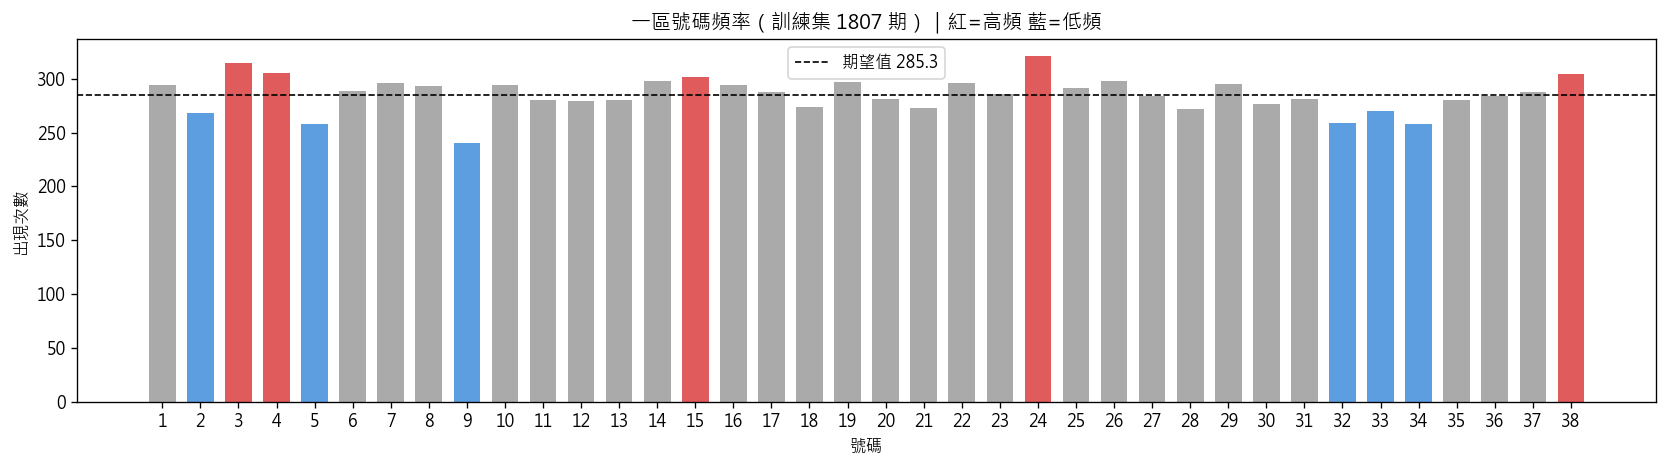

In [3]:
freq_z1 = pd.Series(all_z1).value_counts().reindex(range(1, 39), fill_value=0).sort_index()
expected_z1 = len(df) * 6 / 38

chi2_z1, p_z1 = stats.chisquare(freq_z1)
print(f"一區卡方檢定：χ²={chi2_z1:.2f}，p={p_z1:.4f}")
print(f"→ {'有顯著偏差（p<0.05）' if p_z1 < 0.05 else '無顯著偏差，符合均勻分布'}")

fig, ax = plt.subplots(figsize=(14, 4))
colors = ["#e05c5c" if f > expected_z1 * 1.05 else "#5c9ee0" if f < expected_z1 * 0.95 else "#aaaaaa"
          for f in freq_z1]
ax.bar(freq_z1.index, freq_z1.values, color=colors, width=0.7)
ax.axhline(expected_z1, color="black", linestyle="--", linewidth=1, label=f"期望值 {expected_z1:.1f}")
ax.set_xlabel("號碼")
ax.set_ylabel("出現次數")
ax.set_title(f"一區號碼頻率（訓練集 {len(df)} 期）｜紅=高頻 藍=低頻")
ax.set_xticks(range(1, 39))
ax.legend()
plt.tight_layout()
plt.show()

## 3. 二區號碼頻率分布

二區卡方檢定：χ²=6.58，p=0.4736
→ 無顯著偏差，符合均勻分布


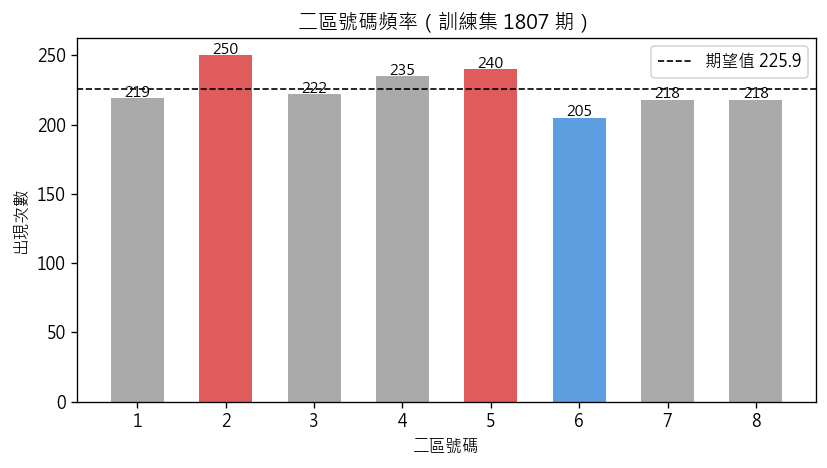

In [4]:
freq_z2 = pd.Series(all_z2).value_counts().reindex(range(1, 9), fill_value=0).sort_index()
expected_z2 = len(df) / 8

chi2_z2, p_z2 = stats.chisquare(freq_z2)
print(f"二區卡方檢定：χ²={chi2_z2:.2f}，p={p_z2:.4f}")
print(f"→ {'有顯著偏差（p<0.05）' if p_z2 < 0.05 else '無顯著偏差，符合均勻分布'}")

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#e05c5c" if f > expected_z2 * 1.05 else "#5c9ee0" if f < expected_z2 * 0.95 else "#aaaaaa"
          for f in freq_z2]
ax.bar(freq_z2.index, freq_z2.values, color=colors, width=0.6)
ax.axhline(expected_z2, color="black", linestyle="--", linewidth=1, label=f"期望值 {expected_z2:.1f}")
for i, (n, v) in enumerate(zip(freq_z2.index, freq_z2.values)):
    ax.text(n, v + 1, str(v), ha="center", fontsize=9)
ax.set_xlabel("二區號碼")
ax.set_ylabel("出現次數")
ax.set_title(f"二區號碼頻率（訓練集 {len(df)} 期）")
ax.set_xticks(range(1, 9))
ax.legend()
plt.tight_layout()
plt.show()

## 4. 年度趨勢：各號平均頻率熱力圖

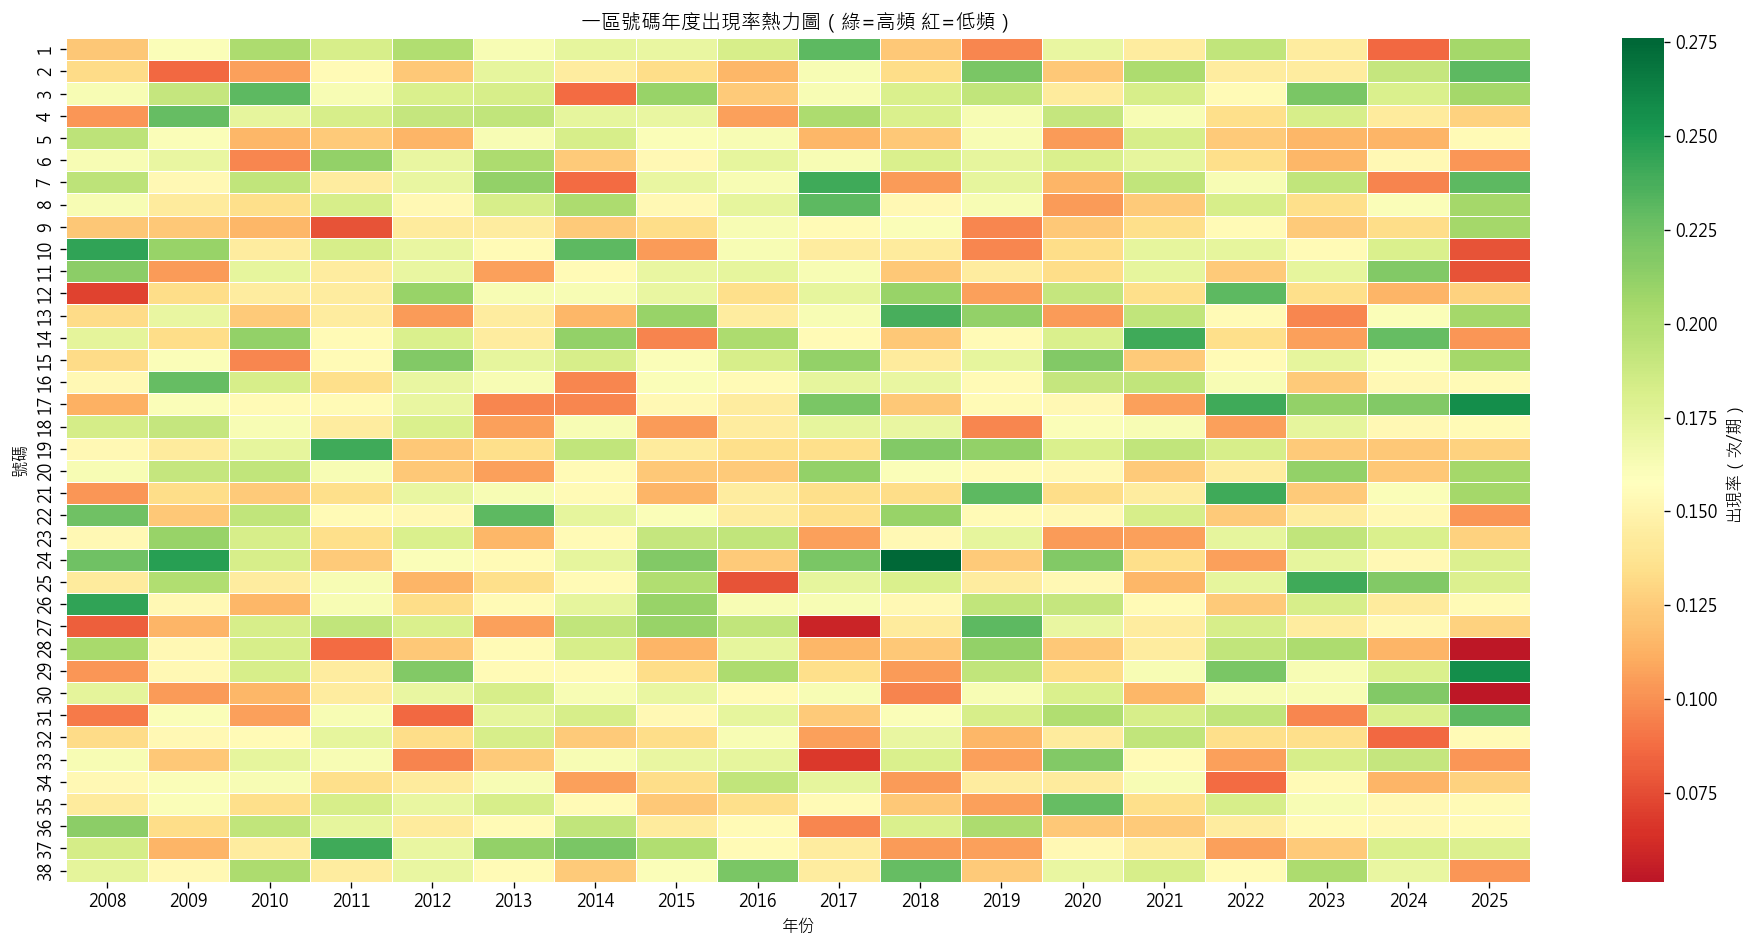

In [5]:
df["year"] = df["draw_date"].dt.year

# 每年每號出現次數 / 該年期數 → 相對頻率
rows = []
for yr, grp in df.groupby("year"):
    n_draws = len(grp)
    counts = pd.Series(grp[zone1_cols].values.flatten()).value_counts()
    for num in range(1, 39):
        rows.append({"year": yr, "num": num, "rate": counts.get(num, 0) / n_draws})

heatmap_df = pd.DataFrame(rows).pivot(index="num", columns="year", values="rate")

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    heatmap_df,
    cmap="RdYlGn",
    center=6/38,
    linewidths=0.3,
    ax=ax,
    cbar_kws={"label": "出現率（次/期）"},
)
ax.set_title("一區號碼年度出現率熱力圖（綠=高頻 紅=低頻）")
ax.set_xlabel("年份")
ax.set_ylabel("號碼")
plt.tight_layout()
plt.show()

## 5. 每期六號總和分布

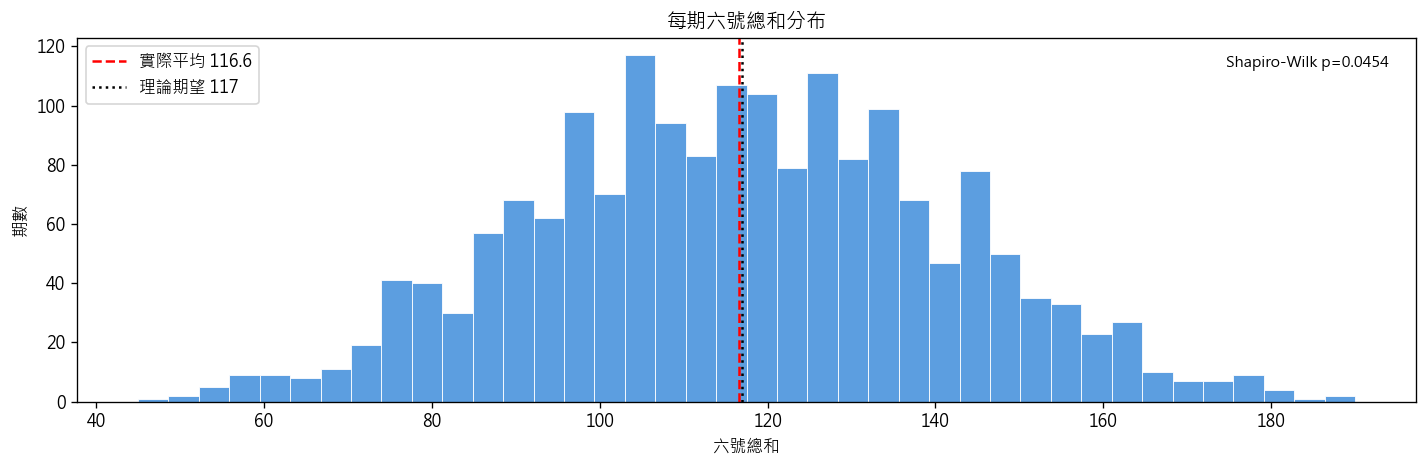

偏度：0.024，峰度：-0.283


In [6]:
# 理論期望值（從 1-38 無放回取 6 的期望總和）= 6 * 39/2 = 117
theoretical_mean = 6 * 39 / 2

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(df["sum6"], bins=40, color="#5c9ee0", edgecolor="white", linewidth=0.5)
ax.axvline(df["sum6"].mean(), color="red", linestyle="--", label=f"實際平均 {df['sum6'].mean():.1f}")
ax.axvline(theoretical_mean, color="black", linestyle=":", label=f"理論期望 {theoretical_mean:.0f}")
ax.set_xlabel("六號總和")
ax.set_ylabel("期數")
ax.set_title("每期六號總和分布")
ax.legend()

# 常態性檢定
_, p_norm = stats.shapiro(df["sum6"])
ax.text(0.98, 0.95, f"Shapiro-Wilk p={p_norm:.4f}", transform=ax.transAxes,
        ha="right", va="top", fontsize=9)

plt.tight_layout()
plt.show()
print(f"偏度：{df['sum6'].skew():.3f}，峰度：{df['sum6'].kurt():.3f}")

## 6. 奇偶比分布

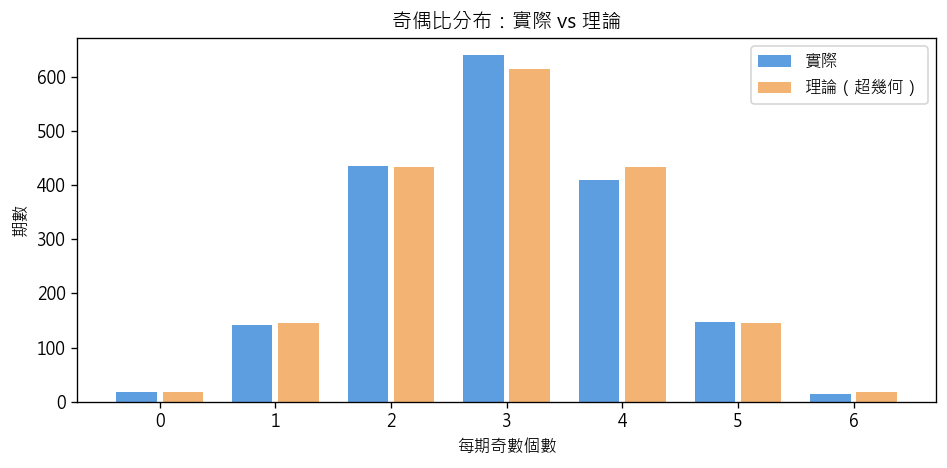

奇偶比卡方檢定：χ²=2.93，p=0.8174
→ 符合超幾何理論分布


In [7]:
df["odd_count"] = df[zone1_cols].apply(lambda r: (r % 2 == 1).sum(), axis=1)
odd_dist = df["odd_count"].value_counts().sort_index()

# 理論機率：從 19 奇 19 偶的 38 號中取 6 的超幾何分布
from scipy.stats import hypergeom
theoretical_odd = {k: hypergeom.pmf(k, 38, 19, 6) * len(df) for k in range(7)}

fig, ax = plt.subplots(figsize=(8, 4))
x = range(7)
ax.bar([i - 0.2 for i in x], [odd_dist.get(i, 0) for i in x],
       width=0.35, label="實際", color="#5c9ee0")
ax.bar([i + 0.2 for i in x], [theoretical_odd[i] for i in x],
       width=0.35, label="理論（超幾何）", color="#f0a050", alpha=0.8)
ax.set_xlabel("每期奇數個數")
ax.set_ylabel("期數")
ax.set_title("奇偶比分布：實際 vs 理論")
ax.set_xticks(list(x))
ax.legend()
plt.tight_layout()
plt.show()

# 卡方檢定
obs = [odd_dist.get(i, 0) for i in range(7)]
exp = [theoretical_odd[i] for i in range(7)]
chi2_odd, p_odd = stats.chisquare(obs, f_exp=exp)
print(f"奇偶比卡方檢定：χ²={chi2_odd:.2f}，p={p_odd:.4f}")
print(f"→ {'有顯著偏差' if p_odd < 0.05 else '符合超幾何理論分布'}")

## 7. 區段分布（1–13 / 14–26 / 27–38）

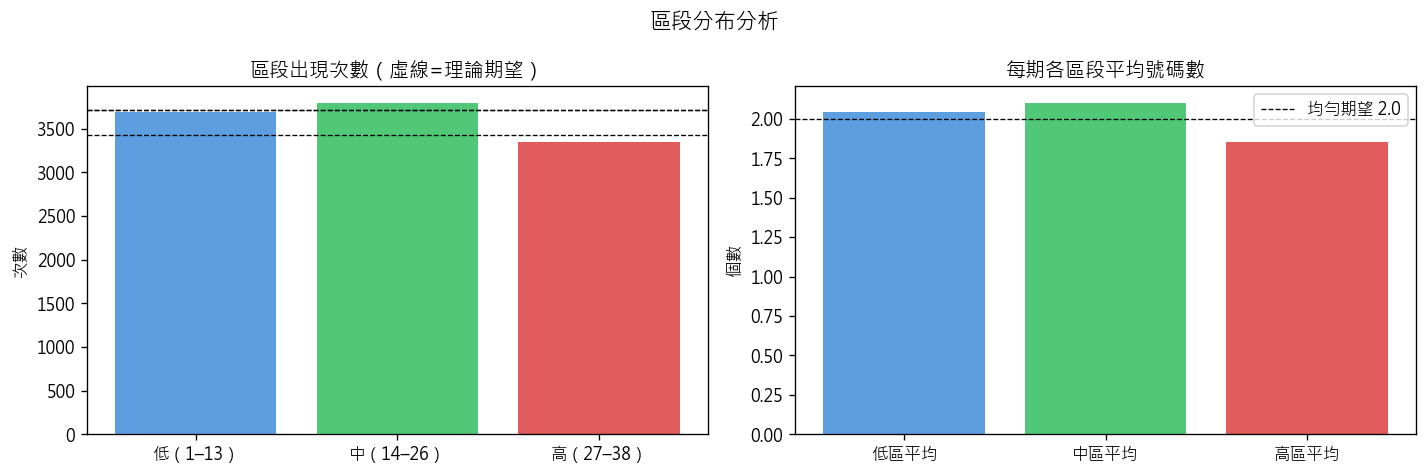

區段卡方檢定：χ²=3.77，p=0.1517
→ 符合理論分布


In [8]:
def segment(n):
    if n <= 13:
        return "低（1–13）"
    elif n <= 26:
        return "中（14–26）"
    else:
        return "高（27–38）"

seg_counts = pd.Series(all_z1).map(segment).value_counts()
seg_order = ["低（1–13）", "中（14–26）", "高（27–38）"]
seg_sizes = [13, 13, 12]  # 號碼數量
total_draws_z1 = len(df) * 6
expected_seg = [s / 38 * total_draws_z1 for s in seg_sizes]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左：各區段次數
axes[0].bar(seg_order, [seg_counts.get(s, 0) for s in seg_order],
            color=["#5c9ee0", "#50c878", "#e05c5c"])
for i, (s, e) in enumerate(zip(seg_order, expected_seg)):
    axes[0].axhline(e, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("區段出現次數（虛線=理論期望）")
axes[0].set_ylabel("次數")

# 右：每期各區段號碼數分布（熱圖替代：用 countplot）
def count_seg(row, lo, hi):
    return sum(lo <= v <= hi for v in row)

df["seg_lo"] = df[zone1_cols].apply(lambda r: count_seg(r, 1, 13), axis=1)
df["seg_mid"] = df[zone1_cols].apply(lambda r: count_seg(r, 14, 26), axis=1)
df["seg_hi"] = df[zone1_cols].apply(lambda r: count_seg(r, 27, 38), axis=1)

seg_mean = df[["seg_lo", "seg_mid", "seg_hi"]].mean()
axes[1].bar(["低區平均", "中區平均", "高區平均"], seg_mean.values,
            color=["#5c9ee0", "#50c878", "#e05c5c"])
axes[1].axhline(2.0, color="black", linestyle="--", linewidth=0.8, label="均勻期望 2.0")
axes[1].set_title("每期各區段平均號碼數")
axes[1].set_ylabel("個數")
axes[1].legend()

plt.suptitle("區段分布分析", fontsize=13)
plt.tight_layout()
plt.show()

chi2_seg, p_seg = stats.chisquare(
    [seg_counts.get(s, 0) for s in seg_order], f_exp=expected_seg
)
print(f"區段卡方檢定：χ²={chi2_seg:.2f}，p={p_seg:.4f}")
print(f"→ {'有顯著偏差' if p_seg < 0.05 else '符合理論分布'}")

## 8. EDA 小結

In [9]:
print("=" * 50)
print("Phase 0 EDA 小結")
print("=" * 50)
results = [
    ("一區號碼均勻性", chi2_z1, p_z1),
    ("二區號碼均勻性", chi2_z2, p_z2),
    ("奇偶比（超幾何）", chi2_odd, p_odd),
    ("區段分布均勻性", chi2_seg, p_seg),
]
for name, chi2, p in results:
    signal = "⚠️ 有偏差" if p < 0.05 else "✅ 無偏差"
    print(f"  {signal}  {name}：χ²={chi2:.2f}，p={p:.4f}")

print()
print("結論：若所有項目均無偏差 → 靜態頻率方向（Order A 機械偏差）無訊號")
print("      Phase 1 仍繼續做跨期 transition（Order B，馬可夫鏈思維）")
print()
print(f"⚠️  Holdout 100 期（最後 100 期）完全未使用，保持鎖定直到 Phase 2")

Phase 0 EDA 小結
  ✅ 無偏差  一區號碼均勻性：χ²=34.21，p=0.6006
  ✅ 無偏差  二區號碼均勻性：χ²=6.58，p=0.4736
  ✅ 無偏差  奇偶比（超幾何）：χ²=2.93，p=0.8174
  ✅ 無偏差  區段分布均勻性：χ²=3.77，p=0.1517

結論：若所有項目均無偏差 → 靜態頻率方向（Order A 機械偏差）無訊號
      Phase 1 仍繼續做跨期 transition（Order B，馬可夫鏈思維）

⚠️  Holdout 100 期（最後 100 期）完全未使用，保持鎖定直到 Phase 2
